# Assignment 2: Data Structures and Methods for HPC
Group 15

- NG, Cheuk Nam (cnng@kth.se)
- Wong, Chun Him (chwon@kth.se)

## Imports

In [207]:
import ipytest
import pytest
import random
import time
import numpy as np
import scipy.stats
from IPython.display import display, Markdown


ipytest.autoconfig()

## Julia Set Code

In [12]:
# area of complex space to investigate
x1, x2, y1, y2 = -1.8, 1.8, -1.8, 1.8
c_real, c_imag = -0.62772, -0.42193

def calc_pure_python(desired_width, max_iterations):
    """Create a list of complex coordinates (zs) and complex parameters (cs),
    build Julia set"""
    x_step = (x2 - x1) / desired_width
    y_step = (y1 - y2) / desired_width
    x = []
    y = []
    ycoord = y2
    while ycoord > y1:
        y.append(ycoord)
        ycoord += y_step
    xcoord = x1
    while xcoord < x2:
        x.append(xcoord)
        xcoord += x_step
    # build a list of coordinates and the initial condition for each cell.
    # Note that our initial condition is a constant and could easily be removed,
    # we use it to simulate a real-world scenario with several inputs to our
    # function
    zs = []
    cs = []
    for ycoord in y:
        for xcoord in x:
            zs.append(complex(xcoord, ycoord))
            cs.append(complex(c_real, c_imag))

    print("Length of x:", len(x))
    print("Total elements:", len(zs))
    start_time = time.time()
    output = calculate_z_serial_purepython(max_iterations, zs, cs)
    end_time = time.time()
    secs = end_time - start_time
    print(calculate_z_serial_purepython.__name__ + " took", secs, "seconds")

    # This sum is expected for a 1000^2 grid with 300 iterations
    # It ensures that our code evolves exactly as we'd intended
    # assert sum(output) == 33219980
    return output

def calculate_z_serial_purepython(maxiter, zs, cs):
    """Calculate output list using Julia update rule"""
    output = [0] * len(zs)
    for i in range(len(zs)):
        n = 0
        z = zs[i]
        c = cs[i]
        while abs(z) < 2 and n < maxiter:
            z = z * z + c
            n += 1
        output[i] = n
    return output

if __name__ == "__main__":
    # Calculate the Julia set using a pure Python solution with
    # reasonable defaults for a laptop
    calc_pure_python(desired_width=1000, max_iterations=300)

calculate_z_serial_purepython took 1.8392739295959473 seconds


# Exercise 1: PyTest with the Julia Set Code

## Task 1.1: Implement a separate code to test the assertion above using the pytest framework
An extra return statement has been added to the `calc_pure_python` function to return the output list. The test function `test_output_sum_for_300_iterations` uses pytest to assert that the sum of the output list for 300 iterations is equal to 33219980.

> The test function below uses the `ipytest` magic command to run pytest within a Jupyter notebook cell. In normal Python files, a `@pytest` decorator would be used instead.

In [23]:
%%ipytest -qq

def test_output_sum_for_300_iterations():
    assert sum(
        calc_pure_python(desired_width=1000, max_iterations=300)
    ) == 33219980

## Task 1.2: How would you implement the unit test with the possibility of having a different number of iterations and grid points?

The above test function in Task 1.1 can be modified to be parameterised as follows:

In [21]:
@pytest.mark.parametrize(
    "width, iterations, expected_sum",
    [
        (1000, 300, 33219980)
    ],
)
def test_output_sum_for_300_iterations_parameterised(width, iterations, expected_sum):
    assert sum(
        calc_pure_python(desired_width=width, max_iterations=iterations)
    ) == expected_sum

# Exercise 2: Python DGEMM Benchmark Operation

## Task 2.1: Implement the DGEMM with matrices as NumPy array

In [94]:
def dgemm_numpy(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> None:
    m, p = a.shape
    n = b.shape[1]

    for i in range(m):
        for j in range(n):
            for k in range(p):
                c[i, j] += a[i, k] * b[k, j]

## Task 2.2: Using pytest develop a unit test for checking the correctness

In [99]:
%%ipytest -qq

def test_dgemm_numpy():
    a = np.array([[11.5, 3.007], [7.0, 11.0]])
    b = np.array([[8.0, 0.0, 1.0], [0.329, 3.0, 5.0]])
    c = np.array([[2.0, 3.0, 9.0], [7.912, 1.0, 2.0]])
    expected_c = np.array([[94.989303, 12.021, 35.535], [67.531, 34.0, 64.0]])
    dgemm_numpy(a, b, c)
    np.testing.assert_array_almost_equal(c, expected_c)

## Task 2.3: Measure the execution time for each approach varying the matrix size


### Code for implementing with Python lists

In [111]:
def dgemm_list(a: list, b: list, c: list) -> None:
    m = len(a)
    p = len(a[0])
    n = len(b[0])

    for i in range(m):
        for j in range(n):
            for k in range(p):
                c[i][j] += a[i][k] * b[k][j]

In [112]:
%%ipytest -qq

def test_dgemm_list():
    a = [[11.5, 3.007], [7.0, 11.0]]
    b = [[8.0, 0.0, 1.0], [0.329, 3.0, 5.0]]
    c = [[2.0, 3.0, 9.0], [7.912, 1.0, 2.0]]
    expected_c = [[94.989303, 12.021, 35.535], [67.531, 34.0, 64.0]]
    dgemm_list(a, b, c)
    np.testing.assert_array_almost_equal(c, expected_c)

### Code for implementing with Python tuples (arrays)

In [114]:
def dgemm_tuple(a: tuple, b: tuple, c: tuple) -> tuple:
    m = len(a)
    p = len(a[0])
    n = len(b[0])

    return tuple(
        tuple(
            c[i][j] + sum(a[i][k] * b[k][j] for k in range(p))
            for j in range(n)
        )
        for i in range(m)
    )

In [115]:
%%ipytest -qq

def test_dgemm_tuple():
    a = ((11.5, 3.007), (7.0, 11.0))
    b = ((8.0, 0.0, 1.0), (0.329, 3.0, 5.0))
    c = ((2.0, 3.0, 9.0), (7.912, 1.0, 2.0))
    expected_c = ((94.989303, 12.021, 35.535), (67.531, 34.0, 64.0))
    new_c = dgemm_tuple(a, b, c)
    np.testing.assert_array_almost_equal(new_c, expected_c)

### Benchmarking

In [192]:
def benchmark_sweep(dgemm_func, init_func, name, start=5, end=100, step=5, iterations=20):
    """
    Runs dgemm_func over a range of matrix sizes and plots the statistics.
    """
    sizes = list(range(start, end + 1, step))
    means, mins, maxs = [], [], []
    cis = [] # Margin of error for CI
    stds = []

    table_lines = [
        f"### Detailed Results: {name}",
        "| Matrix Size | Average (s) | Std Dev (s) | Min (s) | Max (s) | 95% CI Margin (s) |",
        "|:---:|:---:|:---:|:---:|:---:|:---:|"
    ]

    print(f"Running benchmark sweep for {name}...")

    for n in sizes:
        durations = []
        for _ in range(iterations):
            # Initialize matrices using the provided helper
            a, b, c = init_func(n)

            start_time = time.time()
            dgemm_func(a, b, c)
            end_time = time.time()

            durations.append(end_time - start_time)

        # Statistics
        arr = np.array(durations)
        avg = np.mean(arr)
        std = np.std(arr, ddof=1)
        means.append(avg)
        mins.append(np.min(arr))
        maxs.append(np.max(arr))
        stds.append(std)

        # 95% Confidence Interval calculation
        # CI = mean +/- margin_of_error
        # margin_of_error = t * (std / sqrt(n))
        dof = iterations - 1
        t_crit = np.abs(scipy.stats.t.ppf((1 - 0.95) / 2, dof))
        margin_of_error = t_crit * (std / np.sqrt(iterations))
        cis.append(margin_of_error)

        row = f"| {n}x{n} | {avg:.4e} | {std:.4e} | {np.min(arr):.4e} | {np.max(arr):.4e} | ±{margin_of_error:.4e} |"
        table_lines.append(row)

    display(Markdown("\n".join(table_lines)))

#### Benchmarking for Python lists

##### Initialiser

In [172]:
def init_list_matrices(n):
    a = [[random.random() for _ in range(n)] for _ in range(n)]
    b = [[random.random() for _ in range(n)] for _ in range(n)]
    c = [[0.0 for _ in range(n)] for _ in range(n)]
    return a, b, c

##### Benchmark Execution

In [204]:
benchmark_sweep(dgemm_list, init_list_matrices, "Python Lists", start=10, end=100, step=10, iterations=50)

### Detailed Results: Python Lists
| Matrix Size | Average (s) | Std Dev (s) | Min (s) | Max (s) | 95% CI Margin (s) |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 10x10 | 8.1687e-05 | 9.9661e-06 | 7.1049e-05 | 1.2088e-04 | ±2.8323e-06 |
| 20x20 | 4.8196e-04 | 6.7472e-05 | 3.9196e-04 | 6.8784e-04 | ±1.9175e-05 |
| 30x30 | 1.1182e-03 | 9.5056e-05 | 9.7013e-04 | 1.3838e-03 | ±2.7015e-05 |
| 40x40 | 2.4643e-03 | 9.3585e-05 | 2.2547e-03 | 2.7499e-03 | ±2.6596e-05 |
| 50x50 | 4.9397e-03 | 1.8874e-04 | 4.5300e-03 | 5.4290e-03 | ±5.3638e-05 |
| 60x60 | 8.3588e-03 | 1.2205e-04 | 8.0299e-03 | 8.7471e-03 | ±3.4685e-05 |
| 70x70 | 1.3137e-02 | 2.1648e-04 | 1.2641e-02 | 1.3634e-02 | ±6.1523e-05 |
| 80x80 | 1.9637e-02 | 2.5855e-04 | 1.8815e-02 | 2.0101e-02 | ±7.3479e-05 |
| 90x90 | 2.8377e-02 | 6.5097e-04 | 2.7314e-02 | 2.9595e-02 | ±1.8500e-04 |
| 100x100 | 3.8517e-02 | 5.4605e-04 | 3.7727e-02 | 4.0397e-02 | ±1.5519e-04 |

#### Benchmarking for Python tuples

##### Initialiser

In [194]:
def init_tuple_matrices(n):
    """Initializes matrices as tuples for the requested size n."""
    a = tuple(tuple(random.random() for _ in range(n)) for _ in range(n))
    b = tuple(tuple(random.random() for _ in range(n)) for _ in range(n))
    c = tuple(tuple(0.0 for _ in range(n)) for _ in range(n))
    return a, b, c

##### Benchmark Execution

In [203]:
benchmark_sweep(dgemm_tuple, init_tuple_matrices, "Python Tuples", start=10, end=100, step=10, iterations=50)

### Detailed Results: Python Tuples
| Matrix Size | Average (s) | Std Dev (s) | Min (s) | Max (s) | 95% CI Margin (s) |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 10x10 | 1.0435e-04 | 2.6962e-05 | 9.1791e-05 | 2.4700e-04 | ±7.6626e-06 |
| 20x20 | 4.8028e-04 | 6.3528e-05 | 3.9411e-04 | 6.8784e-04 | ±1.8055e-05 |
| 30x30 | 1.0978e-03 | 7.6868e-05 | 9.7513e-04 | 1.2569e-03 | ±2.1846e-05 |
| 40x40 | 2.4012e-03 | 8.4583e-05 | 2.2280e-03 | 2.7461e-03 | ±2.4038e-05 |
| 50x50 | 4.6327e-03 | 1.3172e-04 | 4.3452e-03 | 4.8969e-03 | ±3.7436e-05 |
| 60x60 | 7.9803e-03 | 2.2889e-04 | 7.5471e-03 | 8.4639e-03 | ±6.5048e-05 |
| 70x70 | 1.2452e-02 | 3.2135e-04 | 1.2045e-02 | 1.3240e-02 | ±9.1326e-05 |
| 80x80 | 1.8023e-02 | 2.8103e-04 | 1.7452e-02 | 1.8982e-02 | ±7.9867e-05 |
| 90x90 | 2.5635e-02 | 5.2794e-04 | 2.5105e-02 | 2.7178e-02 | ±1.5004e-04 |
| 100x100 | 3.4453e-02 | 1.7509e-04 | 3.4091e-02 | 3.5347e-02 | ±4.9760e-05 |

#### Benchmarking for NumPy arrays

##### Initialiser

In [189]:
def init_numpy_matrices(n):
    """Initializes matrices as NumPy arrays for the requested size n."""
    a = np.random.rand(n, n)
    b = np.random.rand(n, n)
    c = np.zeros((n, n))
    return a, b, c

##### Benchmark Execution

In [201]:
benchmark_sweep(dgemm_numpy, init_numpy_matrices, "NumPy Arrays", start=10, end=100, step=10, iterations=50)

### Detailed Results: NumPy Arrays
| Matrix Size | Average (s) | Std Dev (s) | Min (s) | Max (s) | 95% CI Margin (s) |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 10x10 | 2.9938e-04 | 3.4639e-05 | 2.5010e-04 | 3.8910e-04 | ±9.8442e-06 |
| 20x20 | 1.6458e-03 | 1.5185e-04 | 1.5182e-03 | 2.1276e-03 | ±4.3156e-05 |
| 30x30 | 5.2404e-03 | 1.4341e-04 | 5.0781e-03 | 5.7080e-03 | ±4.0755e-05 |
| 40x40 | 1.2726e-02 | 3.7605e-04 | 1.2066e-02 | 1.4115e-02 | ±1.0687e-04 |
| 50x50 | 2.4407e-02 | 6.7536e-04 | 2.3508e-02 | 2.5853e-02 | ±1.9194e-04 |
| 60x60 | 4.3653e-02 | 5.2564e-03 | 4.0631e-02 | 6.2964e-02 | ±1.4939e-03 |
| 70x70 | 7.9405e-02 | 2.8232e-02 | 6.4548e-02 | 2.0552e-01 | ±8.0235e-03 |
| 80x80 | 9.7417e-02 | 6.7181e-04 | 9.5891e-02 | 9.9707e-02 | ±1.9093e-04 |
| 90x90 | 1.3842e-01 | 9.3904e-04 | 1.3693e-01 | 1.4129e-01 | ±2.6687e-04 |
| 100x100 | 1.9191e-01 | 2.5164e-03 | 1.8833e-01 | 2.0141e-01 | ±7.1514e-04 |

#### Benchmark Results Analysis

The results indicate that Python lists and tuples yield comparable average computation times. Contrary to common expectation, NumPy arrays do not outperform either structure, despite their optimised C implementation. This arises because the nested loops in the DGEMM implementation bypass NumPy's vectorised operations, resulting in performance akin to that of native Python data structures. Indeed, direct element access in NumPy arrays proves slower than in lists or tuples, with computation times approximately one order of magnitude higher. This might be attributed to the overhead of NumPy's internal handling of array accesses, having to create temporary Python `float` objects for each element access.

As matrix dimensions increase, both the mean computation time and the standard deviation rise. The growth in mean time is expected, given the O(n³) complexity of the algorithm. The increase in standard deviation and consequently the widening of the confidence interval likely stems from greater susceptibility to external interference during longer executions. Such interference may include additional context switches, scheduling delays, or other system-level activity. For larger matrices, cache misses and increased main-memory access would further contribute to execution-time variability.

## Task 2.4: Using the timing information and the number of operations for the DGEMM, calculate the FLOPS/s

In each of the DGEMM implementations, the total number of floating-point operations (FLOPs) for multiplying two n x n matrices is given by $2n^3$ as each loop iteration contains one floating-point multiplication and one floating-point addition.

Taking the average execution time of a 100 x 100 matrix multiplication using Python Lists as an example, which is approximately 0.038517 seconds, we can calculate the FLOPS/s as follows:

$$
\text{FLOPS/s} = \frac{2(100)^3}{0.038517} \approx 51925124 \text{ FLOPS/s}
$$

All the results for this task are done on Apple M4 chip. Assuming that one operation is done per cycle, then the theoretical peak is the clock frequency value: 4.3 GHz or 4.3 x 10^9 FLOPS/s.

This implies that the achieved performance of approximately 51.9 MFLOPS/s is about 1.2% of the theoretical peak performance of the Apple M4 chip and one floating point operation might not be done per cycle.

## Task 2.5: Compare the performance results with the numpy matmul operation

In [53]:
def dgemm_numpy_matmul(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> None:
    c += np.matmul(a, b)

### Benchmark Execution

In [202]:
benchmark_sweep(dgemm_numpy_matmul, init_numpy_matrices, "NumPy Arrays with matmul", start=10, end=100, step=10, iterations=50)

### Detailed Results: NumPy Arrays with matmul
| Matrix Size | Average (s) | Std Dev (s) | Min (s) | Max (s) | 95% CI Margin (s) |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 10x10 | 2.9278e-06 | 6.3969e-06 | 7.1526e-07 | 3.2187e-05 | ±1.8180e-06 |
| 20x20 | 3.3760e-06 | 6.5312e-06 | 9.5367e-07 | 4.2915e-05 | ±1.8561e-06 |
| 30x30 | 2.7084e-06 | 3.4933e-06 | 9.5367e-07 | 2.6226e-05 | ±9.9279e-07 |
| 40x40 | 3.1185e-06 | 2.5442e-06 | 1.6689e-06 | 1.5974e-05 | ±7.2305e-07 |
| 50x50 | 4.7922e-06 | 5.0655e-06 | 2.8610e-06 | 3.1948e-05 | ±1.4396e-06 |
| 60x60 | 4.2772e-06 | 6.0433e-07 | 3.8147e-06 | 7.1526e-06 | ±1.7175e-07 |
| 70x70 | 6.1131e-06 | 7.7183e-07 | 4.7684e-06 | 9.0599e-06 | ±2.1935e-07 |
| 80x80 | 6.8426e-06 | 8.1352e-07 | 5.7220e-06 | 1.0967e-05 | ±2.3120e-07 |
| 90x90 | 9.5367e-06 | 2.0345e-06 | 8.8215e-06 | 2.3127e-05 | ±5.7819e-07 |
| 100x100 | 1.1983e-05 | 1.3425e-06 | 1.0967e-05 | 1.8120e-05 | ±3.8153e-07 |

## Benchmark Results Analysis for NumPy matmul

The NumPy `matmul` function significantly outperforms the custom DGEMM implementation using NumPy arrays, tuples and lists. This is expected, as `matmul` leverages optimised low-level libraries (BLAS) that are vectorised. The performance difference becomes more evident with increasing matrix sizes, despite the runtime for smaller matrices remain similar. It can also be observed that the standard deviation and confidence intervals for `matmul` remains relatively constant across matrix sizes, indicating consistent performance likely due to efficient memory access patterns and optimised algorithms.

# Exercise 3: Experiment with the Python Debugger

## Task 3.1: What are the advantages of using a debugger? What challenges did you find in using the pdb debugger, if any?

One of the advantages of using a debugger is that one can inspect the state of variables at any point during execution, eliminating the need for programmers to rely on print statements. Additionally, it enables programmers to step through the code line by line, placing the flow of execution under a direct control.

Although this is one of my first experiences using the Python debugger, I found it very easy to use, given my prior experience with LLDB and GDB. It also provides useful pretty-printing functionality. However, compared to LLDB, the debugger appears less feature-rich, lacking capabilities such as reverse stepping. Overall, I encountered no significant challenges when using pdb.

# Bonus Exercise: Performance Analysis and Optimization of the Game of Life Code

## Task B.1

#### Pylint

In [ ]:
pylint conway.py 
************* Module conway
conway.py:11:31: C0303: Trailing whitespace (trailing-whitespace)
conway.py:24:38: C0303: Trailing whitespace (trailing-whitespace)
conway.py:25:38: C0303: Trailing whitespace (trailing-whitespace)
conway.py:59:28: C0303: Trailing whitespace (trailing-whitespace)
conway.py:64:70: C0303: Trailing whitespace (trailing-whitespace)
conway.py:66:62: C0303: Trailing whitespace (trailing-whitespace)
conway.py:67:62: C0303: Trailing whitespace (trailing-whitespace)
conway.py:68:74: C0303: Trailing whitespace (trailing-whitespace)
conway.py:95:0: C0303: Trailing whitespace (trailing-whitespace)
conway.py:100:0: C0303: Trailing whitespace (trailing-whitespace)
conway.py:127:18: C0303: Trailing whitespace (trailing-whitespace)
conway.py:80:0: R1707: Disallow trailing comma tuple (trailing-comma-tuple)
conway.py:9:0: C0410: Multiple imports on one line (sys, argparse) (multiple-imports)
conway.py:12:0: R0402: Use 'from matplotlib import animation' instead (consider-using-from-import)
conway.py:18:0: C0103: Function name "randomGrid" doesn't conform to snake_case naming style (invalid-name)
conway.py:18:15: C0103: Argument name "N" doesn't conform to snake_case naming style (invalid-name)
conway.py:22:0: C0103: Function name "addGlider" doesn't conform to snake_case naming style (invalid-name)
conway.py:29:0: C0103: Function name "addGosperGliderGun" doesn't conform to snake_case naming style (invalid-name)
conway.py:57:0: C0116: Missing function or method docstring (missing-function-docstring)
conway.py:57:11: C0103: Argument name "frameNum" doesn't conform to snake_case naming style (invalid-name)
conway.py:57:32: C0103: Argument name "N" doesn't conform to snake_case naming style (invalid-name)
conway.py:60:4: C0103: Variable name "newGrid" doesn't conform to snake_case naming style (invalid-name)
conway.py:57:11: W0613: Unused argument 'frameNum' (unused-argument)
conway.py:83:0: C0116: Missing function or method docstring (missing-function-docstring)
conway.py:97:4: C0103: Variable name "N" doesn't conform to snake_case naming style (invalid-name)
conway.py:99:8: C0103: Variable name "N" doesn't conform to snake_case naming style (invalid-name)
conway.py:102:4: C0103: Variable name "updateInterval" doesn't conform to snake_case naming style (invalid-name)
conway.py:104:8: C0103: Variable name "updateInterval" doesn't conform to snake_case naming style (invalid-name)
conway.py:9:0: W0611: Unused import sys (unused-import)

-----------------------------------
Your code has been rated at 6.18/10


#### Black

In [ ]:
"""
conway_original.py

A simple Python/matplotlib implementation of Conway's Game of Life.

Author: Mahesh Venkitachalam
"""

import sys, argparse
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

ON = 255
OFF = 0
vals = [ON, OFF]


def randomGrid(N):
    """returns a grid of NxN random values"""
    return np.random.choice(vals, N * N, p=[0.2, 0.8]).reshape(N, N)


def addGlider(i, j, grid):
    """adds a glider with top left cell at (i, j)"""
    glider = np.array([[0, 0, 255], [255, 0, 255], [0, 255, 255]])
    grid[i : i + 3, j : j + 3] = glider


def addGosperGliderGun(i, j, grid):
    """adds a Gosper Glider Gun with top left cell at (i, j)"""
    gun = np.zeros(11 * 38).reshape(11, 38)

    gun[5][1] = gun[5][2] = 255
    gun[6][1] = gun[6][2] = 255

    gun[3][13] = gun[3][14] = 255
    gun[4][12] = gun[4][16] = 255
    gun[5][11] = gun[5][17] = 255
    gun[6][11] = gun[6][15] = gun[6][17] = gun[6][18] = 255
    gun[7][11] = gun[7][17] = 255
    gun[8][12] = gun[8][16] = 255
    gun[9][13] = gun[9][14] = 255

    gun[1][25] = 255
    gun[2][23] = gun[2][25] = 255
    gun[3][21] = gun[3][22] = 255
    gun[4][21] = gun[4][22] = 255
    gun[5][21] = gun[5][22] = 255
    gun[6][23] = gun[6][25] = 255
    gun[7][25] = 255

    gun[3][35] = gun[3][36] = 255
    gun[4][35] = gun[4][36] = 255

    grid[i : i + 11, j : j + 38] = gun

def step(grid, N):
    #for profiling only
    newGrid = grid.copy()
    for i in range(N):
        for j in range(N):
            total = int(
                (
                    grid[i, (j - 1) % N]
                    + grid[i, (j + 1) % N]
                    + grid[(i - 1) % N, j]
                    + grid[(i + 1) % N, j]
                    + grid[(i - 1) % N, (j - 1) % N]
                    + grid[(i - 1) % N, (j + 1) % N]
                    + grid[(i + 1) % N, (j - 1) % N]
                    + grid[(i + 1) % N, (j + 1) % N]
                )
                / 255
            )
            if grid[i, j] == ON:
                if (total < 2) or (total > 3):
                    newGrid[i, j] = OFF
            else:
                if total == 3:
                    newGrid[i, j] = ON
    return newGrid
    
def update(frameNum, img, grid, N):
    # copy grid since we require 8 neighbors for calculation
    # and we go line by line
    newGrid = grid.copy()
    for i in range(N):
        for j in range(N):
            # compute 8-neghbor sum
            # using toroidal boundary conditions - x and y wrap around
            # so that the simulaton takes place on a toroidal surface.
            total = int(
                (
                    grid[i, (j - 1) % N]
                    + grid[i, (j + 1) % N]
                    + grid[(i - 1) % N, j]
                    + grid[(i + 1) % N, j]
                    + grid[(i - 1) % N, (j - 1) % N]
                    + grid[(i - 1) % N, (j + 1) % N]
                    + grid[(i + 1) % N, (j - 1) % N]
                    + grid[(i + 1) % N, (j + 1) % N]
                )
                / 255
            )
            # apply Conway's rules
            if grid[i, j] == ON:
                if (total < 2) or (total > 3):
                    newGrid[i, j] = OFF
            else:
                if total == 3:
                    newGrid[i, j] = ON
    # update data
    img.set_data(newGrid)
    grid[:] = newGrid[:]
    return (img,)


# main() function
def main():
    # Command line args are in sys.argv[1], sys.argv[2] ..
    # sys.argv[0] is the script name itself and can be ignored
    # parse arguments
    parser = argparse.ArgumentParser(
        description="Runs Conway's Game of Life simulation."
    )
    # add arguments
    parser.add_argument("--grid-size", dest="N", required=False)
    parser.add_argument("--mov-file", dest="movfile", required=False)
    parser.add_argument("--interval", dest="interval", required=False)
    parser.add_argument("--glider", action="store_true", required=False)
    parser.add_argument("--gosper", action="store_true", required=False)
    args = parser.parse_args()

    # set grid size
    N = 100
    if args.N and int(args.N) > 8:
        N = int(args.N)

    # set animation update interval
    updateInterval = 50
    if args.interval:
        updateInterval = int(args.interval)

    # declare grid
    grid = np.array([])
    # check if "glider" demo flag is specified
    if args.glider:
        grid = np.zeros(N * N).reshape(N, N)
        addGlider(1, 1, grid)
    elif args.gosper:
        grid = np.zeros(N * N).reshape(N, N)
        addGosperGliderGun(10, 10, grid)
    else:
        # populate grid with random on/off - more off than on
        grid = randomGrid(N)

    # set up animation
    fig, ax = plt.subplots()
    img = ax.imshow(grid, interpolation="nearest")
    ani = animation.FuncAnimation(
        fig,
        update,
        fargs=(
            img,
            grid,
            N,
        ),
        frames=10,
        interval=updateInterval,
        save_count=50,
    )

    # # of frames?
    # set output file
    if args.movfile:
        ani.save(args.movfile, fps=30, extra_args=["-vcodec", "libx264"])

    plt.show()


# call main
if __name__ == "__main__":
    main()


#### Sphinx (HTML documentation)

In [ ]:
sphinx-build -b html docs docs/_build/html
Running Sphinx v9.0.4
loading translations [en]... done
loading pickled environment... The configuration has changed (1 option: 'html_static_path')
done
building [mo]: targets for 0 po files that are out of date
writing output... 
building [html]: build_info mismatch, copying .buildinfo to .buildinfo.bak
building [html]: targets for 1 source files that are out of date
updating environment: 0 added, 0 changed, 0 removed
reading sources... 
looking for now-outdated files... none found
preparing documents... done
copying assets... 
copying static files... 
Writing evaluated template result to /Users/klaus/Documents/KTH/DD2358/dd2358-work/docs/_build/html/_static/basic.css
Writing evaluated template result to /Users/klaus/Documents/KTH/DD2358/dd2358-work/docs/_build/html/_static/language_data.js
Writing evaluated template result to /Users/klaus/Documents/KTH/DD2358/dd2358-work/docs/_build/html/_static/documentation_options.js
Writing evaluated template result to /Users/klaus/Documents/KTH/DD2358/dd2358-work/docs/_build/html/_static/alabaster.css
copying static files: done
copying extra files... 
copying extra files: done
copying assets: done
writing output... [100%] index
generating indices... genindex py-modindex done
writing additional pages... search done
dumping search index in English (code: en)... done
dumping object inventory... done
build succeeded.

The HTML pages are in docs/_build/html.

## Task B.2

Measure execution time while **varying grid size** and keeping the **number of iterations fixed**. We run the **original** Game of Life code (**`conway_original.py`**). Plot grid size vs execution time.

In [2]:
import sys, os, time
import matplotlib.pyplot as plt

if os.path.isfile(os.path.join(os.getcwd(), "asm2", "conway_original.py")):
    sys.path.insert(0, os.path.join(os.getcwd(), "asm2"))
else:
    sys.path.insert(0, os.getcwd())
import conway_original

num_iterations = 100
grid_sizes = [200, 400, 600, 800, 1000]
times_sec = []
for N in grid_sizes:
    grid = conway_original.randomGrid(N)
    t0 = time.perf_counter()
    for _ in range(num_iterations):
        grid = conway_original.step(grid, N)
    t = time.perf_counter() - t0
    times_sec.append(t)
    print(f"N={N}: {t:.4f} s")
plt.plot(grid_sizes, times_sec, "o-")
plt.xlabel("Grid size N")
plt.ylabel("Time (s)")
plt.title("Original (conway_original.py): time vs grid size")
plt.grid(True)
plt.show()

N=200: 3.4198 s
N=400: 14.6212 s


KeyboardInterrupt: 

## Task B.3

### Coarse-grained: cProfile (function-level)

In [5]:
import cProfile, pstats, sys, os
if os.path.isfile(os.path.join(os.getcwd(), "asm2", "conway_original.py")):
    sys.path.insert(0, os.path.join(os.getcwd(), "asm2"))
else:
    sys.path.insert(0, os.getcwd())
import conway_original

def benchmark():
    N, iters = 150, 50
    grid = conway_original.randomGrid(N)
    for _ in range(iters):
        grid = conway_original.step(grid, N)
pr = cProfile.Profile()
pr.enable()
benchmark()
pr.disable()
pstats.Stats(pr).sort_stats("cumulative").print_stats(15)

=== cProfile (coarse): top 15 by cumulative time (conway_original.py) ===

         158 function calls in 1.479 seconds

   Ordered by: cumulative time
   List reduced from 32 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    1.479    0.740 /opt/miniconda3/envs/profiling/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3665(run_code)
        2    0.000    0.000    1.479    0.740 {built-in method builtins.exec}
        1    0.000    0.000    1.479    1.479 /var/folders/1w/8txt8lgn7ts1bxz2rxxd4y9c0000gn/T/ipykernel_41668/3108166553.py:16(benchmark)
       50    1.477    0.030    1.478    0.030 /Users/klaus/Documents/KTH/DD2358/dd2358-work/asm2/conway_original.py:59(step)
        1    0.001    0.001    0.001    0.001 /Users/klaus/Documents/KTH/DD2358/dd2358-work/asm2/conway_original.py:19(randomGrid)
       50    0.001    0.000    0.001    0.000 {method 'copy' of 'numpy.ndarray' objects}
     

### Fine-grained: line_profiler 

In [6]:
import sys, os
if os.path.isfile(os.path.join(os.getcwd(), "asm2", "conway_original.py")):
    sys.path.insert(0, os.path.join(os.getcwd(), "asm2"))
else:
    sys.path.insert(0, os.getcwd())
import conway_original

%load_ext line_profiler
%lprun -f conway_original.step conway_original.step(conway_original.randomGrid(80), 80)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


Timer unit: 1e-09 s

Total time: 0.026689 s
File: /Users/klaus/Documents/KTH/DD2358/dd2358-work/asm2/conway_original.py
Function: step at line 59

Line #      Hits         Time  Per Hit   % Time  Line Contents
    59                                           def step(grid, N):
    60                                               """One simulation step (no visualization). For profiling; same logic as inside update()."""
    61         1     586000.0 586000.0      2.2      newGrid = grid.copy()
    62        81      15000.0    185.2      0.1      for i in range(N):
    63      6480     492000.0     75.9      1.8          for j in range(N):
    64     12800    1482000.0    115.8      5.6              total = int(
    65      6400    1045000.0    163.3      3.9                  (
    66     51200    7091000.0    138.5     26.6                      grid[i, (j - 1) % N]
    67      6400    1498000.0    234.1      5.6                      + grid[i, (j + 1) % N]
    68      6400    1798000.0  

## Task B.4

In [3]:
"""
conway.py

A simple Python/matplotlib implementation of Conway's Game of Life.

Author: Mahesh Venkitachalam
"""

import sys, argparse
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

ON = 255
OFF = 0
vals = [ON, OFF]


def randomGrid(N):
    """returns a grid of NxN random values"""
    return np.random.choice(vals, N * N, p=[0.2, 0.8]).reshape(N, N)


def addGlider(i, j, grid):
    """adds a glider with top left cell at (i, j)"""
    glider = np.array([[0, 0, 255], [255, 0, 255], [0, 255, 255]])
    grid[i : i + 3, j : j + 3] = glider


def addGosperGliderGun(i, j, grid):
    """adds a Gosper Glider Gun with top left cell at (i, j)"""
    gun = np.zeros(11 * 38).reshape(11, 38)

    gun[5][1] = gun[5][2] = 255
    gun[6][1] = gun[6][2] = 255

    gun[3][13] = gun[3][14] = 255
    gun[4][12] = gun[4][16] = 255
    gun[5][11] = gun[5][17] = 255
    gun[6][11] = gun[6][15] = gun[6][17] = gun[6][18] = 255
    gun[7][11] = gun[7][17] = 255
    gun[8][12] = gun[8][16] = 255
    gun[9][13] = gun[9][14] = 255

    gun[1][25] = 255
    gun[2][23] = gun[2][25] = 255
    gun[3][21] = gun[3][22] = 255
    gun[4][21] = gun[4][22] = 255
    gun[5][21] = gun[5][22] = 255
    gun[6][23] = gun[6][25] = 255
    gun[7][25] = 255

    gun[3][35] = gun[3][36] = 255
    gun[4][35] = gun[4][36] = 255

    grid[i : i + 11, j : j + 38] = gun


def step(grid, N):
    # Neighbor count: sum 8 rolled views (toroidal wrap)
    rU = np.roll(grid, -1, axis=0)
    rD = np.roll(grid, 1, axis=0)
    rL = np.roll(grid, -1, axis=1)
    rR = np.roll(grid, 1, axis=1)
    rUL = np.roll(rU, -1, axis=1)
    rUR = np.roll(rU, 1, axis=1)
    rDL = np.roll(rD, -1, axis=1)
    rDR = np.roll(rD, 1, axis=1)
    n = (
        (rU + rD + rL + rR + rUL + rUR + rDL + rDR) / 255
    ).astype(np.int_)
    # Conway rules: birth (dead + 3 neighbors) or survive (live + 2 or 3)
    live = grid == ON
    birth = ~live & (n == 3)
    survive = live & ((n == 2) | (n == 3))
    return np.where(birth | survive, ON, OFF).astype(grid.dtype)


def update(frameNum, img, grid, N):
    """Animation callback: one step using optimized step()."""
    newGrid = step(grid, N)
    img.set_data(newGrid)
    grid[:] = newGrid[:]
    return (img,)


# main() function
def main():
    # Command line args are in sys.argv[1], sys.argv[2] ..
    # sys.argv[0] is the script name itself and can be ignored
    # parse arguments
    parser = argparse.ArgumentParser(
        description="Runs Conway's Game of Life simulation."
    )
    # add arguments
    parser.add_argument("--grid-size", dest="N", required=False)
    parser.add_argument("--mov-file", dest="movfile", required=False)
    parser.add_argument("--interval", dest="interval", required=False)
    parser.add_argument("--glider", action="store_true", required=False)
    parser.add_argument("--gosper", action="store_true", required=False)
    args = parser.parse_args()

    # set grid size
    N = 100
    if args.N and int(args.N) > 8:
        N = int(args.N)

    # set animation update interval
    updateInterval = 50
    if args.interval:
        updateInterval = int(args.interval)

    # declare grid
    grid = np.array([])
    # check if "glider" demo flag is specified
    if args.glider:
        grid = np.zeros(N * N).reshape(N, N)
        addGlider(1, 1, grid)
    elif args.gosper:
        grid = np.zeros(N * N).reshape(N, N)
        addGosperGliderGun(10, 10, grid)
    else:
        # populate grid with random on/off - more off than on
        grid = randomGrid(N)

    # set up animation
    fig, ax = plt.subplots()
    img = ax.imshow(grid, interpolation="nearest")
    ani = animation.FuncAnimation(
        fig,
        update,
        fargs=(
            img,
            grid,
            N,
        ),
        frames=10,
        interval=updateInterval,
        save_count=50,
    )

    # # of frames?
    # set output file
    if args.movfile:
        ani.save(args.movfile, fps=30, extra_args=["-vcodec", "libx264"])

    plt.show()


# call main
if __name__ == "__main__":
    main()


usage: ipykernel_launcher.py [-h] [--grid-size N] [--mov-file MOVFILE]
                             [--interval INTERVAL] [--glider] [--gosper]
ipykernel_launcher.py: error: unrecognized arguments: --f=/Users/klaus/Library/Jupyter/runtime/kernel-v3da796aa56e3b768d1821d74cea06d84012bddfa3.json


SystemExit: 2

### Performance comparison: conway_original.py vs conway.py (optimized)

N    | original (s) | optimized (s) | speedup
--------------------------------------------------
 200 |       3.5374 |        0.0539 | 65.6x
 400 |      14.2603 |        0.1719 | 83.0x
 600 |      33.2428 |        0.5774 | 57.6x
 800 |      60.5117 |        1.1346 | 53.3x
1000 |      92.8445 |        1.6878 | 55.0x


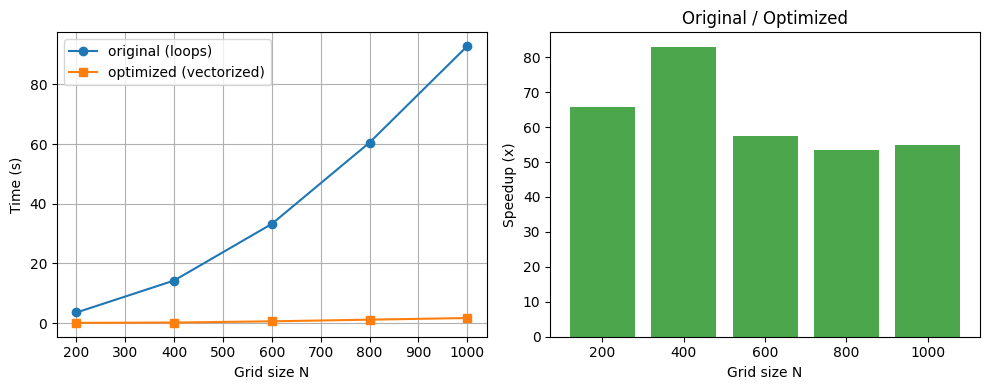

In [4]:
import sys, os, time
import matplotlib.pyplot as plt

if os.path.isfile(os.path.join(os.getcwd(), "asm2", "conway_original.py")):
    sys.path.insert(0, os.path.join(os.getcwd(), "asm2"))
else:
    sys.path.insert(0, os.getcwd())
import conway_original
import conway

num_iterations = 100
grid_sizes = [200, 400, 600, 800, 1000]
times_orig = []
times_opt = []
for N in grid_sizes:
    grid = conway.randomGrid(N)
    t0 = time.perf_counter()
    g = grid.copy()
    for _ in range(num_iterations):
        g = conway_original.step(g, N)
    times_orig.append(time.perf_counter() - t0)
    t0 = time.perf_counter()
    g = grid.copy()
    for _ in range(num_iterations):
        g = conway.step(g, N)
    times_opt.append(time.perf_counter() - t0)
speedups = [times_orig[i] / times_opt[i] for i in range(len(grid_sizes))]
print("N    | original (s) | optimized (s) | speedup")
print("-" * 50)
for i, N in enumerate(grid_sizes):
    print(f"{N:4} | {times_orig[i]:12.4f} | {times_opt[i]:13.4f} | {speedups[i]:.1f}x")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(grid_sizes, times_orig, "o-", label="original (loops)")
ax1.plot(grid_sizes, times_opt, "s-", label="optimized (vectorized)")
ax1.set_xlabel("Grid size N")
ax1.set_ylabel("Time (s)")
ax1.legend()
ax1.grid(True)
ax2.bar(range(len(grid_sizes)), speedups, color="green", alpha=0.7)
ax2.set_xticks(range(len(grid_sizes)))
ax2.set_xticklabels(grid_sizes)
ax2.set_xlabel("Grid size N")
ax2.set_ylabel("Speedup (x)")
ax2.set_title("Original / Optimized")
plt.tight_layout()
plt.show()

### New profiling results

In [16]:
import cProfile, pstats, sys, os
if os.path.isfile(os.path.join(os.getcwd(), "asm2", "conway.py")):
    sys.path.insert(0, os.path.join(os.getcwd(), "asm2"))
else:
    sys.path.insert(0, os.getcwd())
import conway

def run():
    grid = conway.randomGrid(150)
    for _ in range(50):
        grid = conway.step(grid, 150)
pr = cProfile.Profile()
pr.enable()
run()
pr.disable()
pstats.Stats(pr).sort_stats("cumulative").print_stats(12)

         158 function calls in 1.594 seconds

   Ordered by: cumulative time
   List reduced from 32 to 12 due to restriction <12>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    1.593    0.797 /opt/miniconda3/envs/profiling/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3665(run_code)
        2    0.000    0.000    1.593    0.797 {built-in method builtins.exec}
        1    0.001    0.001    1.593    1.593 /var/folders/1w/8txt8lgn7ts1bxz2rxxd4y9c0000gn/T/ipykernel_41668/255385970.py:8(run)
       50    1.565    0.031    1.588    0.032 /Users/klaus/Documents/KTH/DD2358/dd2358-work/asm2/conway.py:59(step)
       50    0.023    0.000    0.023    0.000 {method 'copy' of 'numpy.ndarray' objects}
        1    0.003    0.003    0.003    0.003 /Users/klaus/Documents/KTH/DD2358/dd2358-work/asm2/conway.py:19(randomGrid)
        1    0.000    0.000    0.000    0.000 /opt/miniconda3/envs/profiling/lib/python3.11/site-packages/

## AI Usage
### Composer 1.5
#### Task B.2
Suggested code to plot the graph
#### Task B.3
Brainstorming for what coarse and fine-grained profiler I can use
#### Task B.4
Brainstorming: Ways to further optimization, Suggested code to plot the graph
##### All edited and modified by us.
### Prompts:
#### Task B.2 
"Based on the code I have writen, suggest the code to plot a graph"
#### Task B.3 
"Suggest some coarse and fine-grained profiler with Python for free that I can use"
#### Task B.4 
"Based on the code I provided, can it be further optimized?"
"Based on the code I provided, suggest the code to plot a graph to compare the result with the original and the optimized code."
### Validation:
#### Task B.2 
Modify some format
#### Task B.3 
Choose cProfile and line_profiler which we have used before
#### Task B.4 
Plot and experiment that the suggestion of boolean indexing for the live or dead rools further optimized the code